
# LLM Router — Unified Log Loader
This notebook loads and indexes experiment runs with the unified filenames:
- `metrics.jsonl`
- `output.jsonl`
- `queue.json` (optional)
- `results.json`

It assumes your repo layout like:
```
results/
  rr-batching/
    17/
      metrics.jsonl
      output.jsonl
      queue.json
      results.json
  pull-batching/
    29/
      metrics.jsonl
      output.jsonl
      queue.json
      results.json
...
```

> **Tip:** You can change `BASE_DIR` below if your results are elsewhere.


In [1]:
import pandas as pd

from utils_analysis import (
    make_runs_index,
    load_experiment,
    normalize_metrics_samples,
    collect_results_summary,
    collect_all_metrics,
    collect_all_outputs,
    select_metrics,
    metrics_to_endpoint_tables,
    summarize_output_metric,
    draw_output_time_each,
    summarize_metrics_metric,
    summarize_queue_metric,
    cumulative_output_metric,
    cumulative_metrics_metric,
    cumulative_queue_metric,
    list_available_metrics_metrics,
    list_available_output_metrics,
    list_all_metrics_for_run,
)


BASE_DIR = "/home/saeid/llm-lb/results"  # or "results copy"
SERIES_1 = "1"
SERIES_2 = "1"

# Put only the experiments you want to analyze here:
EXPERIMENTS = [
    ("rr-worker", SERIES_2),
    ("least-queue-worker", SERIES_2),
    ("pull", SERIES_2),
    ("rr-batching", SERIES_1),
    ("least-queue-batching", SERIES_1),
    ("pull-batching", SERIES_1),
    # ("least-queue-batching", "6"),
    # ("random-batching", "5"),
    # ("pull", "5"),
    # ("least-queue-worker", "2"),
    # ("pull-batching", "40"),
    # ("least-queue-batching", "14"),
]

runs_index = make_runs_index(EXPERIMENTS, base_dir=BASE_DIR)
# runs_index

In [2]:
method, run_id = runs_index.iloc[0][["method", "run_id"]]
exp = load_experiment(method, run_id, base_dir=BASE_DIR)

# print("Loaded sections:", list(exp.keys()))
if "results" in exp:
    print("results.json:", exp["results"])

# Peek at raw frames
# display(exp.get("metrics", pd.DataFrame()).head())
# display(exp.get("output", pd.DataFrame()).head())
# display(exp.get("queue", pd.DataFrame()).head())

# Normalize metrics.samples for this run
metrics_norm = normalize_metrics_samples(
    exp.get("metrics", pd.DataFrame()), method, run_id
)
print("Normalized metrics shape:", metrics_norm.shape)
# display(metrics_norm.head())

results.json: {'runtime_sec': 696.7375020980835, 'endpoints': {'http://10.1.62.164:8200': {'ok': 500, 'err': 0}, 'http://10.1.62.135:8200': {'ok': 500, 'err': 0}}, 'total_ok': 1000, 'total_err': 0}
Normalized metrics shape: (1180, 32)


## Nvidia Results

,method,run_id,runtime_sec,endpoints,total_ok,total_err
0,rr-worker,1,696.737502,"{'http://10.1.62.164:8200': {'ok': 500, 'err':...",1000,0
1,least-queue-worker,1,713.768125,"{'http://10.1.62.164:8200': {'ok': 507, 'err':...",1000,0
2,pull,1,695.914888,"{'http://10.1.62.164:8200': {'ok': 515, 'err':...",1000,0
3,rr-batching,1,206.443070,"{'http://10.1.62.135:8200': {'ok': 516, 'err':...",1000,0
4,least-queue-batching,1,205.041703,"{'http://10.1.62.135:8200': {'ok': 506, 'err':...",1000,0
5,pull-batching,1,201.345370,"{'http://10.1.62.135:8200': {'ok': 482, 'err':...",1000,0


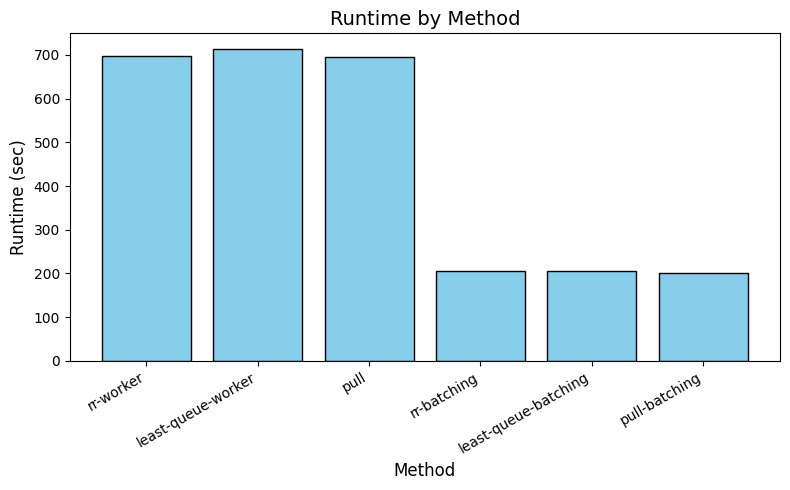

In [3]:
results_summary = collect_results_summary(runs_index)
metrics_all = collect_all_metrics(runs_index)
outputs_all = collect_all_outputs(runs_index)

display(results_summary)
# display(metrics_all.head())
# display(outputs_all.head())

# Optional CSVs for quick offline inspection
# runs_index.to_csv("runs_index.csv", index=False)
# if not results_summary.empty:
#     results_summary.to_csv("results_summary_flat.csv", index=False)
# print("Exports written where available")

import matplotlib.pyplot as plt

# Plot runtime_sec from results_summary
plt.figure(figsize=(8, 5))
plt.bar(
    results_summary["method"],
    results_summary["runtime_sec"],
    color="skyblue",
    edgecolor="black",
)

plt.xlabel("Method", fontsize=12)
plt.ylabel("Runtime (sec)", fontsize=12)
plt.title("Runtime by Method", fontsize=14)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## NPU Results

In [4]:
BASE_DIR = "/home/saeid/llm-lb/results"  # or "results copy"
SERIES_1 = "8"
SERIES_2 = "3"

# Put only the experiments you want to analyze here:
EXPERIMENTS = [
    ("rr-worker", SERIES_2),
    ("least-queue-worker", SERIES_2),
    ("pull", SERIES_2),
    ("rr-batching", SERIES_1),
    ("least-queue-batching", SERIES_1),
    ("pull-batching", SERIES_1),
    # ("least-queue-batching", "6"),
    # ("random-batching", "5"),
    # ("pull", "5"),
    # ("least-queue-worker", "2"),
    # ("pull-batching", "40"),
    # ("least-queue-batching", "14"),
]

runs_index = make_runs_index(EXPERIMENTS, base_dir=BASE_DIR)

## Simulation Results

,method,run_id,runtime_sec,endpoints,total_ok,total_err
0,rr-worker,3,1989.082540,"{'http://10.244.0.110:8200': {'ok': 500, 'err'...",1000,0
1,least-queue-worker,3,1906.879680,"{'http://10.244.0.110:8200': {'ok': 499, 'err'...",1000,0
2,pull,3,1889.691077,"{'http://10.244.0.110:8200': {'ok': 513, 'err'...",1000,0
3,rr-batching,8,571.461792,"{'http://10.244.0.109:8200': {'ok': 468, 'err'...",1000,0
4,least-queue-batching,8,573.019615,"{'http://10.244.0.109:8200': {'ok': 484, 'err'...",1000,0
5,pull-batching,8,564.217055,"{'http://10.244.0.109:8200': {'ok': 478, 'err'...",1000,0


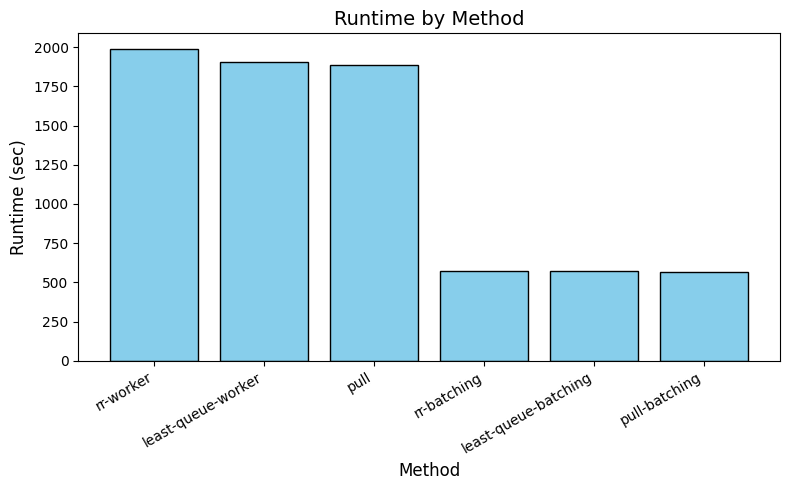

In [5]:
results_summary = collect_results_summary(runs_index)
metrics_all = collect_all_metrics(runs_index)
outputs_all = collect_all_outputs(runs_index)

display(results_summary)
# display(metrics_all.head())
# display(outputs_all.head())

# Optional CSVs for quick offline inspection
# runs_index.to_csv("runs_index.csv", index=False)
# if not results_summary.empty:
#     results_summary.to_csv("results_summary_flat.csv", index=False)
# print("Exports written where available")

import matplotlib.pyplot as plt

# Plot runtime_sec from results_summary
plt.figure(figsize=(8, 5))
plt.bar(
    results_summary["method"],
    results_summary["runtime_sec"],
    color="skyblue",
    edgecolor="black",
)

plt.xlabel("Method", fontsize=12)
plt.ylabel("Runtime (sec)", fontsize=12)
plt.title("Runtime by Method", fontsize=14)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Simulation Results

,method,run_id,runtime_sec,endpoints,total_ok,total_err
0,rr-batching,7,15.685809,"{'http://127.0.0.1:9101': {'ok': 144, 'err': 0...",1000,0
1,least-queue-batching,7,15.985473,"{'http://127.0.0.1:9101': {'ok': 144, 'err': 0...",1000,0
2,pull-batching,7,10.864032,"{'http://127.0.0.1:9101': {'ok': 141, 'err': 0...",1000,0


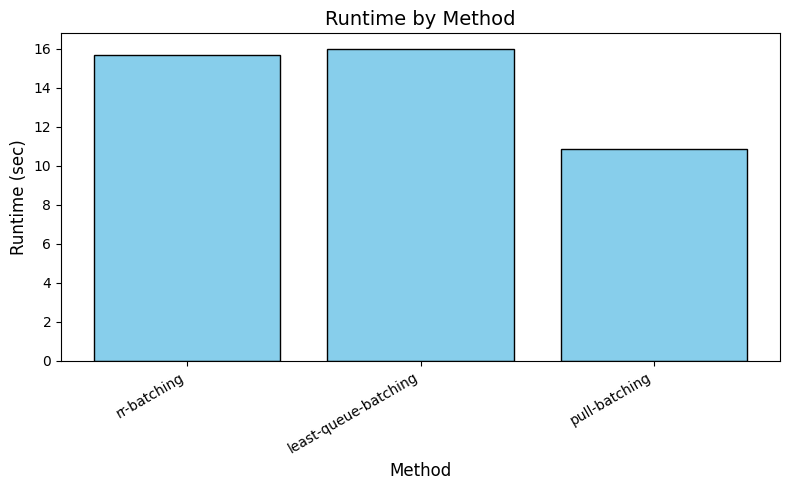

In [6]:
BASE_DIR = "/home/saeid/llm-lb/results"  # or "results copy"
SERIES_1 = "7"
SERIES_2 = "2"

# Put only the experiments you want to analyze here:
EXPERIMENTS = [
    # ("rr-worker", SERIES_2),
    # ("least-queue-worker", SERIES_2),
    # ("pull", SERIES_2),
    ("rr-batching", SERIES_1),
    ("least-queue-batching", SERIES_1),
    ("pull-batching", SERIES_1),
    # ("least-queue-batching", "6"),
    # ("random-batching", "5"),
    # ("pull", "5"),
    # ("least-queue-worker", "2"),
    # ("pull-batching", "40"),
    # ("least-queue-batching", "14"),
]

runs_index = make_runs_index(EXPERIMENTS, base_dir=BASE_DIR)

results_summary = collect_results_summary(runs_index)
metrics_all = collect_all_metrics(runs_index)
outputs_all = collect_all_outputs(runs_index)

display(results_summary)

import matplotlib.pyplot as plt

# Plot runtime_sec from results_summary
plt.figure(figsize=(8, 5))
plt.bar(
    results_summary["method"],
    results_summary["runtime_sec"],
    color="skyblue",
    edgecolor="black",
)

plt.xlabel("Method", fontsize=12)
plt.ylabel("Runtime (sec)", fontsize=12)
plt.title("Runtime by Method", fontsize=14)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

def collect_all_queues(runs_index):
    frames = []
    for _, row in runs_index.iterrows():
        if row["queue_path"]:
            df = read_queue(row["queue_path"])
            df["method"] = row["method"]
            df["run_id"] = row["run_id"]
            frames.append(df)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

queues_all = collect_all_queues(runs_index)
queues_all.head()


## Simulation Results

In [7]:
results_summary = collect_results_summary(runs_index)
metrics_all = collect_all_metrics(runs_index)
outputs_all = collect_all_outputs(runs_index)

display(results_summary)
# display(metrics_all.head())
# display(outputs_all.head())

# Optional CSVs for quick offline inspection
# runs_index.to_csv("runs_index.csv", index=False)
# if not results_summary.empty:
#     results_summary.to_csv("results_summary_flat.csv", index=False)
# print("Exports written where available")

# import matplotlib.pyplot as plt

# # Plot runtime_sec from results_summary
# plt.figure(figsize=(8, 5))
# plt.bar(results_summary["method"], results_summary["runtime_sec"],
#         color="skyblue", edgecolor="black")

# plt.xlabel("Method", fontsize=12)
# plt.ylabel("Runtime (sec)", fontsize=12)
# plt.title("Runtime by Method", fontsize=14)
# plt.xticks(rotation=30, ha="right")
# plt.tight_layout()
# plt.show()

,method,run_id,runtime_sec,endpoints,total_ok,total_err
0,rr-batching,7,15.685809,"{'http://127.0.0.1:9101': {'ok': 144, 'err': 0...",1000,0
1,least-queue-batching,7,15.985473,"{'http://127.0.0.1:9101': {'ok': 144, 'err': 0...",1000,0
2,pull-batching,7,10.864032,"{'http://127.0.0.1:9101': {'ok': 141, 'err': 0...",1000,0


In [8]:
# 2) output.jsonl — latency per request (points), separate figures
# draw_output_time_each(
#     EXPERIMENTS,
#     metric="sim_queue_wait_s",
#     endpoints=None,
#     base_dir=BASE_DIR,
#     per_request=True,  # raw events; resample ignored
#     resample=None,
#     title=None,
#     save_path_template=None,
#     ylim=None
# )

In [9]:
# 2) output.jsonl — latency per request (points), separate figures
# draw_output_time_each(
#     EXPERIMENTS,
#     metric="sim_service_s",
#     endpoints=None,
#     base_dir=BASE_DIR,
#     per_request=True,  # raw events; resample ignored
#     resample=None,
#     title=None,
#     save_path_template=None,
#     ylim=None
# )

In [10]:
# 2) output.jsonl — latency per request (points), separate figures
# draw_output_time_each(
#     EXPERIMENTS,
#     metric="sim_total_wall_s",
#     endpoints=None,
#     base_dir=BASE_DIR,
#     per_request=True,  # raw events; resample ignored
#     resample=None,
#     title=None,
#     save_path_template=None,
#     # ylim=(0, 0.12),
#     ylim=None
# )

In [11]:
# metric="sim_service_s"
# metric="sim_total_wall_s"

# display(summarize_output_metric(
#     "rr-batching", SERIES_1,
#     metric=metric,
#     percentiles=(50, 90, 99),
#     base_dir=BASE_DIR,
#     include_overall=True
# ))

# display(summarize_output_metric(
#     "least-queue-batching", SERIES_1,
#     metric=metric,
#     percentiles=(50, 90, 99),
#     base_dir=BASE_DIR,
#     include_overall=True
# ))

# display(summarize_output_metric(
#     "pull-batching", SERIES_1,
#     metric=metric,
#     percentiles=(50, 90, 99),
#     base_dir=BASE_DIR,
#     include_overall=True
# ))

In [12]:
# metric="sim_service_s"
metric = "latency_s"

display(
    summarize_output_metric(
        "rr-batching",
        SERIES_1,
        metric=metric,
        percentiles=(50, 90, 99),
        base_dir=BASE_DIR,
        include_overall=True,
    )
)

display(
    summarize_output_metric(
        "least-queue-batching",
        SERIES_1,
        metric=metric,
        percentiles=(50, 90, 99),
        base_dir=BASE_DIR,
        include_overall=True,
    )
)

display(
    summarize_output_metric(
        "pull-batching",
        SERIES_1,
        metric=metric,
        percentiles=(50, 90, 99),
        base_dir=BASE_DIR,
        include_overall=True,
    )
)

display(
    summarize_output_metric(
        "rr-worker",
        SERIES_2,
        metric=metric,
        percentiles=(50, 90, 99),
        base_dir=BASE_DIR,
        include_overall=True,
    )
)

display(
    summarize_output_metric(
        "least-queue-worker",
        SERIES_2,
        metric=metric,
        percentiles=(50, 90, 99),
        base_dir=BASE_DIR,
        include_overall=True,
    )
)

display(
    summarize_output_metric(
        "pull",
        SERIES_2,
        metric=metric,
        percentiles=(50, 90, 99),
        base_dir=BASE_DIR,
        include_overall=True,
    )
)

,endpoint,count,sum,mean,std,min,max,p50,p90,p99
0,http://127.0.0.1:9101,144,3.121286,0.021676,0.005793,0.010580,0.036319,0.021300,0.029729,0.035299
1,http://127.0.0.1:9102,144,2.613088,0.018146,0.004817,0.009760,0.032288,0.016853,0.024423,0.031102
2,http://127.0.0.1:9103,144,2.423147,0.016827,0.004316,0.007544,0.027529,0.015920,0.022826,0.026171
3,http://127.0.0.1:9104,144,2.447159,0.016994,0.004563,0.008114,0.034631,0.016449,0.022678,0.032244
4,http://127.0.0.1:9105,144,2.646075,0.018376,0.004400,0.010223,0.028730,0.017972,0.024283,0.027240
5,http://127.0.0.1:9106,140,2.504374,0.017888,0.004897,0.008797,0.036677,0.017186,0.023445,0.033530
6,http://127.0.0.1:9107,140,4.391879,0.031371,0.011227,0.010816,0.062809,0.030255,0.046098,0.060818
7,ALL,1000,20.147007,0.020147,0.007757,0.007544,0.062809,0.018382,0.029800,0.048823


,endpoint,count,sum,mean,std,min,max,p50,p90,p99
0,http://127.0.0.1:9101,144,3.055604,0.021219,0.005307,0.011168,0.040575,0.020389,0.028666,0.034011
1,http://127.0.0.1:9102,144,2.658599,0.018462,0.004512,0.010464,0.033188,0.018165,0.024253,0.030773
2,http://127.0.0.1:9103,144,2.601112,0.018063,0.004251,0.008681,0.029418,0.017256,0.024150,0.027124
3,http://127.0.0.1:9104,144,2.534106,0.017598,0.004167,0.009878,0.034772,0.017260,0.023285,0.027484
4,http://127.0.0.1:9105,144,2.772152,0.019251,0.004882,0.010766,0.040240,0.018456,0.025735,0.035074
5,http://127.0.0.1:9106,140,2.464592,0.017604,0.004266,0.008534,0.027420,0.017288,0.023828,0.026264
6,http://127.0.0.1:9107,140,4.142794,0.029591,0.008301,0.009658,0.047501,0.029307,0.041017,0.046020
7,ALL,1000,20.228959,0.020229,0.006573,0.008534,0.047501,0.018775,0.028384,0.042214


,endpoint,count,sum,mean,std,min,max,p50,p90,p99
0,http://127.0.0.1:9101,141,4.660777,0.033055,0.011176,0.012689,0.088482,0.031758,0.047003,0.062954
1,http://127.0.0.1:9102,140,4.205828,0.030042,0.009868,0.011848,0.065487,0.028860,0.041527,0.063307
2,http://127.0.0.1:9103,143,4.533576,0.031703,0.012410,0.014341,0.088889,0.028505,0.046135,0.076227
3,http://127.0.0.1:9104,143,4.016958,0.028091,0.009923,0.010477,0.074022,0.026759,0.040004,0.057024
4,http://127.0.0.1:9105,148,4.438038,0.029987,0.011207,0.013971,0.072969,0.027858,0.043867,0.066579
5,http://127.0.0.1:9106,144,4.498010,0.031236,0.010960,0.013035,0.070033,0.029690,0.046011,0.065560
6,http://127.0.0.1:9107,141,5.376908,0.038134,0.013610,0.013216,0.104240,0.037412,0.051759,0.070029
7,ALL,1000,31.730095,0.031730,0.011721,0.010477,0.104240,0.029748,0.046276,0.068929


,endpoint,count,sum,mean,std,min,max,p50,p90,p99
0,http://127.0.0.1:9101,143,1.972633,0.013795,0.003072,0.007610,0.020993,0.014885,0.016443,0.020238
1,http://127.0.0.1:9102,143,1.960854,0.013712,0.002605,0.007469,0.020865,0.014676,0.015918,0.018561
2,http://127.0.0.1:9103,143,1.903107,0.013308,0.002704,0.007723,0.022485,0.014215,0.015713,0.018113
3,http://127.0.0.1:9104,143,1.939207,0.013561,0.002660,0.007481,0.020026,0.014598,0.015689,0.019253
4,http://127.0.0.1:9105,143,2.022765,0.014145,0.002747,0.007649,0.018618,0.015160,0.016705,0.018584
5,http://127.0.0.1:9106,143,1.975301,0.013813,0.002917,0.007915,0.025700,0.014889,0.016209,0.019289
6,http://127.0.0.1:9107,142,2.105112,0.014825,0.003827,0.007479,0.042744,0.016071,0.017496,0.019412
7,ALL,1000,13.878979,0.013879,0.002984,0.007469,0.042744,0.014783,0.016628,0.019550


,endpoint,count,sum,mean,std,min,max,p50,p90,p99
0,http://127.0.0.1:9101,1000,13.751216,0.013751,0.003251,0.006417,0.057689,0.014788,0.016211,0.019608
1,ALL,1000,13.751216,0.013751,0.003251,0.006417,0.057689,0.014788,0.016211,0.019608


,endpoint,count,sum,mean,std,min,max,p50,p90,p99
0,http://127.0.0.1:9101,144,2.734756,0.018991,0.007133,0.009840,0.092954,0.018700,0.022680,0.030396
1,http://127.0.0.1:9102,142,2.675247,0.018840,0.007627,0.009257,0.095134,0.018463,0.022641,0.035905
2,http://127.0.0.1:9103,142,2.728663,0.019216,0.005629,0.009704,0.065727,0.018436,0.024899,0.033414
3,http://127.0.0.1:9104,145,2.700860,0.018627,0.005734,0.010020,0.066547,0.018082,0.024050,0.031324
4,http://127.0.0.1:9105,144,2.729030,0.018952,0.010172,0.008618,0.125846,0.017737,0.026253,0.031651
5,http://127.0.0.1:9106,146,2.719205,0.018625,0.005255,0.008563,0.061624,0.018490,0.022838,0.029053
6,http://127.0.0.1:9107,137,2.698517,0.019697,0.005346,0.008394,0.049270,0.019719,0.023947,0.041045
7,ALL,1000,18.986279,0.018986,0.006895,0.008394,0.125846,0.018494,0.023908,0.032747


In [13]:
# Show full responses + response length grouped by prompt

# df_long = outputs_all[
#     ["prompt", "run_id", "method", "response_preview", "latency_s"]
# ].copy()

# # Add response length
# df_long["resp_len"] = df_long["response_preview"].astype(str).str.len()

# # Sort for readability
# df_long = df_long.sort_values(["prompt", "run_id"]).reset_index(drop=True)

# pd.set_option("display.max_colwidth", None)

# for prompt, group in df_long.groupby("prompt"):
#     print("=" * 120)
#     print(f"Prompt: {prompt}\n")
#     for _, row in group.iterrows():
#         label = f"{row['method']}/{row['run_id']} | latency={row['latency_s']:.2f}s | length={row['resp_len']}"
#         print(f"[{label}]\n{row['response_preview']}\n")

In [14]:
# from utils_analysis import draw_metric_time

# method = "rr-batching"
# run_id = "9"
# metric = "requests_running"  # e.g., "gpu_util_percent", "gen_tokens_per_sec"
# endpoints = None  # or ["http://10.1.62.151:8200"]
# resample = None  # e.g., "1S" to bin by 1 second (mean)
# title = None
# save_to = None

# draw_metric_time(
#     method,
#     run_id,
#     metric,
#     endpoints=endpoints,
#     base_dir=BASE_DIR,
#     resample=resample,
#     title=title,
#     save_path=save_to,
# )

In [15]:
# from utils_analysis import draw_output_time

# method = "rr-batching"
# run_id = "9"
# metric = "latency_s"
# endpoints = None
# # When per_request=True, resample is ignored
# draw_output_time(
#     method,
#     run_id,
#     metric,
#     endpoints=endpoints,
#     base_dir=BASE_DIR,
#     resample=None,
#     per_request=True,  # raw per-request points
#     title=None,
#     save_path=None,
# )

In [16]:
# from utils_analysis import draw_output_time

# method = "rr-batching"
# run_id = "9"
# metric = "latency_s"  # request/event-driven; use mean when resampling
# endpoints = None
# resample = "1S"  # optional smoothing
# title = None
# save_to = None

# draw_output_time(
#     method,
#     run_id,
#     metric,
#     endpoints=endpoints,
#     base_dir=BASE_DIR,
#     resample=resample,
#     title=title,
#     save_path=save_to,
# )

In [17]:
# from utils_analysis import draw_queue_time

# method = "rr-batching"
# run_id = "10"
# metric = "inflight_after"  # state-driven; plotted as steps
# endpoints = None
# resample = "0.1S"  # optional; uses last+ffill per bin
# title = None
# save_to = None

# draw_queue_time(
#     method,
#     run_id,
#     metric,
#     endpoints=endpoints,
#     base_dir=BASE_DIR,
#     resample=resample,
#     title=title,
#     save_path=save_to,
# )